# Stochastic evolution of a colony of B cells in dimension 1
Compare with least action

In [23]:
import matplotlib.pyplot as plt
from __future__ import annotations
import numpy as np
from numpy.random import default_rng

Simulating...
Simulation ended with 80 cells.
Found 0 cells with 5 <= h < 6.


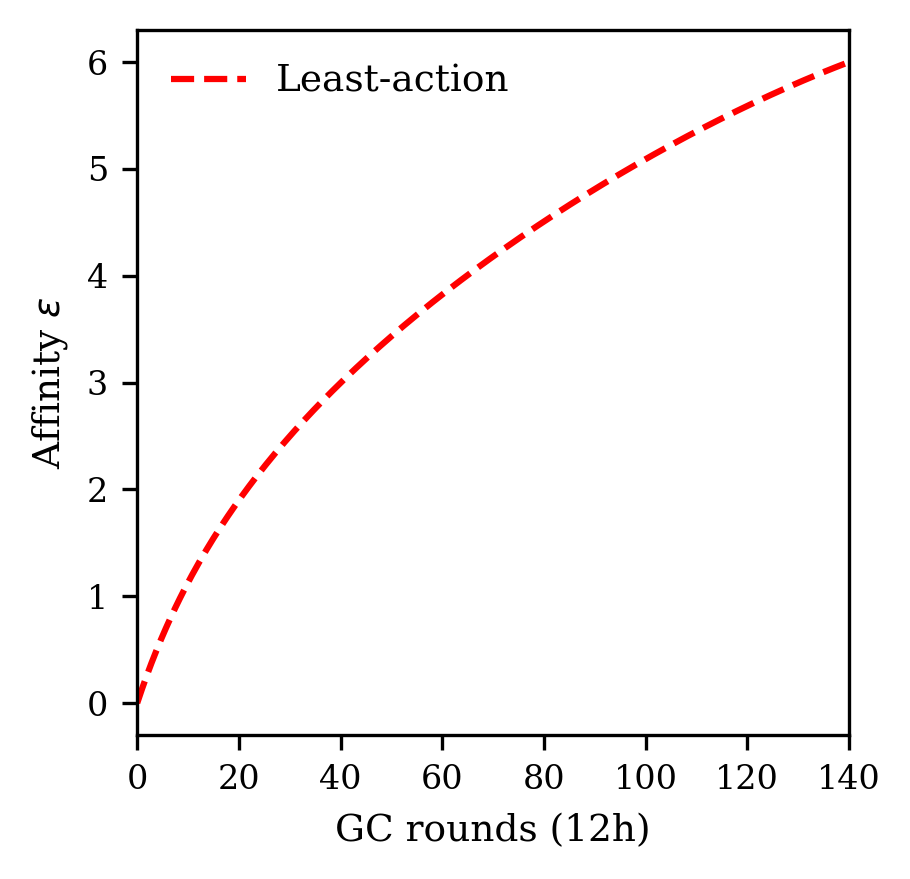

In [ ]:
import numpy as np
from numpy.random import default_rng
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib import rcParams

# --------------------- biological / model parameters -------------------
mu_M = -0.8
sigma_M = 1.09
S_mat = None  # defined later

mu = 0.001 * 3 * 40
p_sil = 0.5 * (mu) + (1 - mu)
p_let = 0.3 * (mu)
p_aa = 0.2 * (mu)
E_a = np.log(40)
T_steps = 140
kBT = 1
N_i = 2500
N_max = 2500
mu_i = 0.0
sigma_i = 0.001
p_diff = 0.10
c = 170

# -------------------------- helper functions ---------------------------
def energies(pop: np.ndarray, S_mat: np.ndarray) -> np.ndarray:
    """Compute energies for every cell and every antigen."""
    return pop @ S_mat

def P_Ag(eps: np.ndarray, C_vec: np.ndarray) -> np.ndarray:
    """Antigen-binding survival gate."""
    exp_term = np.exp((eps - E_a) / kBT)
    numer = (exp_term * C_vec).sum(axis=1)
    return numer / (1.0 + numer)

def P_T(eps: np.ndarray, C_vec: np.ndarray) -> np.ndarray:
    """T-cell-help survival gate."""
    C_tot = C_vec.sum()
    eE = np.exp(eps / kBT)
    Phi = (eE * C_vec).sum(axis=1)
    Phi_bar = Phi.mean()
    if C_tot == 0: return np.zeros_like(Phi)
    return Phi / (Phi + Phi_bar / C_tot)

# ----------------------- one maturation round --------------------------
def gc_round(pop: np.ndarray,
             ids: np.ndarray,
             next_uid: int,
             S_mat: np.ndarray,
             C_vec: np.ndarray,
             rng: np.random.Generator):
    """
    Advance the cycling population by one GC round, tracking IDs.
    
    Returns:
        pop: New population vectors
        ids: New population IDs
        parent_ids: The parent ID for each cell in the new population
        next_uid: Updated global ID counter
        mem_data: Tuple of (mem_pop, mem_ids, mem_parent_ids)
    """
    # 1. Duplication (Tracking Lineage) -------------------------------
    # Parents become the parent_ids for the next generation
    n_parents = pop.shape[0]
    
    # Repeat phenotypes
    pop = np.repeat(pop, 2, axis=0)
    
    # The 'ids' of the current step become 'parent_ids' of the next step
    parent_ids = np.repeat(ids, 2)
    
    # Generate fresh unique IDs for the new daughter cells
    ids = np.arange(next_uid, next_uid + 2 * n_parents, dtype=np.int64)
    next_uid += 2 * n_parents

    # 2. Somatic hyper-mutation ---------------------------------------
    N_cells = pop.shape[0]
    fate = rng.choice(["let", "aa", "sil"], size=N_cells, p=[p_let, p_aa, p_sil])

    alive_mask = fate != "let"
    aa_mask = fate == "aa"
    n_aa = aa_mask.sum()

    if n_aa:
        idx_sites = rng.integers(0, pop.shape[1], size=n_aa)
        delta_h = rng.normal(mu_M, sigma_M, size=n_aa)
        pop[aa_mask, idx_sites] = pop[aa_mask, idx_sites] + delta_h

    # Apply lethal filter to all parallel arrays
    pop = pop[alive_mask]
    ids = ids[alive_mask]
    parent_ids = parent_ids[alive_mask]
    
    if pop.size == 0:
        return pop, ids, parent_ids, next_uid, (np.empty((0, pop.shape[1])), np.array([]), np.array([]))

    # 3. Antigen-binding gate -----------------------------------------
    eps = energies(pop, S_mat)
    P_ag = P_Ag(eps, C_vec)
    survive = rng.random(size=P_ag.size) < P_ag
    
    pop = pop[survive]
    ids = ids[survive]
    parent_ids = parent_ids[survive]
    eps = eps[survive]
    
    if pop.size == 0:
        return pop, ids, parent_ids, next_uid, (np.empty((0, S_mat.shape[0])), np.array([]), np.array([]))

    # 4. T-cell-help gate ---------------------------------------------
    P_t = P_T(eps, C_vec)
    survive = rng.random(size=P_t.size) < P_t
    
    pop = pop[survive]
    ids = ids[survive]
    parent_ids = parent_ids[survive]
    
    if pop.size == 0:
        return pop, ids, parent_ids, next_uid, (np.empty((0, S_mat.shape[0])), np.array([]), np.array([]))

    # 5. Differentiation ----------------------------------------------
    diff_mask = rng.random(size=pop.shape[0]) < p_diff
    
    # Extract memory cells
    mem_pop = pop[diff_mask]
    mem_ids = ids[diff_mask]
    mem_parent_ids = parent_ids[diff_mask]
    
    # Keep cycling cells
    pop = pop[~diff_mask]
    ids = ids[~diff_mask]
    parent_ids = parent_ids[~diff_mask]

    return pop, ids, parent_ids, next_uid, (mem_pop, mem_ids, mem_parent_ids)

# ---------------------- full GC simulation driver ----------------------
def simulate_gc_with_ancestry(rounds: int,
                              S_mat: np.ndarray,
                              N_init: int = N_i,
                              N_max: int = N_max,
                              C_schedule = lambda r: np.array([c]),
                              mu_init: float = mu_i,
                              sigma_init: float = sigma_i,
                              seed: int | None = None):
    """
    Simulates GC and stores ID and Parent_ID to reconstruction lineages.
    """
    rng = default_rng(seed)
    N_h = S_mat.shape[0]

    # Initialize
    pop = rng.normal(mu_init, sigma_init, size=(N_init, N_h))
    
    # Assign initial IDs (0 to N_init-1)
    # Parent ID -1 indicates "Founder" (start of simulation)
    ids = np.arange(N_init, dtype=np.int64)
    parent_ids = np.full(N_init, -1, dtype=np.int64)
    next_uid = N_init

    # History will store dictionaries now
    history = []
    
    # Store state 0
    history.append({
        'pop': pop.copy(),
        'ids': ids.copy(),
        'parent_ids': parent_ids.copy()
    })

    for r in range(rounds):
        C_vec = np.asarray(C_schedule(r), dtype=float)#tODO: 
        
        # Run round
        pop, ids, parent_ids, next_uid, _mem = gc_round(
            pop, ids, next_uid, S_mat, C_vec, rng
        )

        # Population Cap (Resampling)
        if pop.shape[0] > N_max:
            keep_idx = rng.choice(pop.shape[0], N_max, replace=False)
            pop = pop[keep_idx]
            ids = ids[keep_idx]
            parent_ids = parent_ids[keep_idx]

        history.append({
            'pop': pop.copy(),
            'ids': ids.copy(),
            'parent_ids': parent_ids.copy()
        })
        
        if pop.shape[0] == 0:
            break

    return history

# ---------------------- Lineage Reconstruction ----------------------
def trace_lineages(history, target_indices_at_end):
    """
    Reconstructs trajectories for specific cells found in the last step.
    
    Parameters
    ----------
    history : list of dicts
        The output from simulate_gc_with_ancestry.
    target_indices_at_end : array-like
        Indices in the *last* history frame of the cells you want to trace.
        
    Returns
    -------
    trajectories : list of numpy arrays
        A list where each element is an array of shape (T+1, N_h)
        representing the path of a single lineage.
    """
    if not history:
        return []

    # Get the last frame
    final_step = len(history) - 1
    last_frame = history[final_step]
    
    # These are the IDs we want to trace back
    current_ids_to_trace = last_frame['ids'][target_indices_at_end]
    
    # Initialize storage for paths: Dictionary mapping Final_ID -> List of vectors
    # We will trace backwards using IDs
    
    # Map: Final_Unique_ID -> Current_Ancestor_ID
    active_traces = {uid: uid for uid in current_ids_to_trace}
    
    # Storage: Final_Unique_ID -> List of h vectors
    results = {uid: [] for uid in current_ids_to_trace}
    
    for t in range(final_step, -1, -1):
        frame = history[t]
        
        # Create lookup for this frame: ID -> (Index, Parent_ID, Vector)
        # This is O(N) per frame.
        frame_lookup = {uid: (i, pid, vec) 
                       for i, (uid, pid, vec) 
                       in enumerate(zip(frame['ids'], frame['parent_ids'], frame['pop']))}
        
        for final_uid, ancestor_id in list(active_traces.items()):
            if ancestor_id in frame_lookup:
                _, parent_id, vector = frame_lookup[ancestor_id]
                results[final_uid].append(vector)
                
                # Step back: looking for parent in previous frame
                if parent_id != -1:
                    active_traces[final_uid] = parent_id
                else:
                    # Reached root
                    del active_traces[final_uid]
            else:
                # Should not happen in a unbroken chain
                del active_traces[final_uid]
                
    # Reverse lists to get time 0 -> T
    trajectories = []
    for uid in current_ids_to_trace:
        traj = np.array(results[uid][::-1])
        trajectories.append(traj)
        
    return trajectories

# ---------------------- Run & Plot Logic ----------------------

# Setup Single Antigen
S_mat = np.array([[1]])
def C_schedule(r): return np.array([c])

# Run Simulation
print("Simulating...")
history = simulate_gc_with_ancestry(
    rounds=T_steps,
    S_mat=S_mat,
    N_init=N_i,
    N_max=N_max,
    C_schedule=C_schedule,
    seed=1
)

# 1. Identify Target Cells in the Final Population
last_frame = history[-1]
final_pop = last_frame['pop']
final_energies = energies(final_pop, S_mat).flatten()

# Filter: Find indices where 5 <= h < 6
target_indices = np.where((final_energies >= 5.5) & (final_energies < 6.5))[0]

print(f"Simulation ended with {len(final_pop)} cells.")
print(f"Found {len(target_indices)} cells with 5 <= h < 6.")

# 2. Get Trajectories
trajectories = trace_lineages(history, target_indices)


# 3. Plotting using PRL-style settings provided
# --- PRL-style font and layout settings ------------------------------
# rcParams.update({
#     "font.size": 9,
#     "axes.labelsize": 9,
#     "axes.titlesize": 9,
#     "xtick.labelsize": 8,
#     "ytick.labelsize": 8,
#     "lines.linewidth": 1,
#     "lines.markersize": 4,
#     "legend.fontsize": 8,
#     "figure.figsize": (3.4, 2.6),  # ~8.6cm × 6.6cm
#     "figure.dpi": 300,
#     "xtick.direction": "in",
#     "ytick.direction": "in",
# })

plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.markersize": 4,
    "figure.figsize": (3., 3.),  # ≈8.6 cm × 6.6 cm
    "figure.dpi": 300,
    "font.family": "serif",        # Often preferred in papers
})

# --- Load trajectory from CSV ----------------------------------------
try:
    # Try loading the file if it exists
    h_sol = np.loadtxt("../multi Ag/trajectory_h_140.csv", delimiter=",")
    T = T_steps
    n_points = len(h_sol)
    t_sol = np.linspace(0, T, n_points)
except OSError:
    # Fallback if file not found (allows script to run without file)
    print("CSV file '../multi Ag/trajectory_h_140.csv' not found. Skipping least-action trajectory.")
    h_sol = None
    t_sol = None
    T = T_steps

# --- Prepare B-cell lineage trajectories ------------------------------
h1_by_round = defaultdict(list)
fig, ax = plt.subplots()
first = True

# Map existing 'trajectories' list to the logic structure requested
for traj in trajectories:
    h1 = traj.flatten() # 1D antigen assumption
    rounds = np.arange(len(h1))

    for t, h in zip(rounds, h1):
        h1_by_round[t].append(h)
    
    if first:
        ax.plot(rounds, h1, lw=0.5, color='lightgrey', label='Stochastic')
        first = False
    else:
        ax.plot(rounds, h1, lw=0.5, color='lightgrey')

# --- Plot mean trajectory in blue -------------------------------------
if h1_by_round:
    common_rounds = sorted(h1_by_round.keys())
    mean_h1 = [np.mean(h1_by_round[t]) for t in common_rounds]
    ax.plot(common_rounds, mean_h1, lw=1.5, color='red', label='Mean stochastic')

# --- Plot least-action trajectory in red ------------------------------
if h_sol is not None:
    ax.plot(t_sol, h_sol, lw=1.5, color='red', label='Least-action', linestyle='--')

# --- Final formatting -------------------------------------------------
t_max = T_steps
target = "5-6"
ax.set_xlim(0, t_max)
ax.set_xlabel("GC rounds (12h)")
ax.set_ylabel(r"Affinity $\epsilon$")
ax.legend(frameon=False, loc="upper left")
# ax.set_title(r"Lineages reaching affinity $\epsilon\sim6$")
fig.tight_layout()
plt.show()

Target 1: Found 37 cells.
Target 5: Found 358 cells.
Target 7: Found 68 cells.


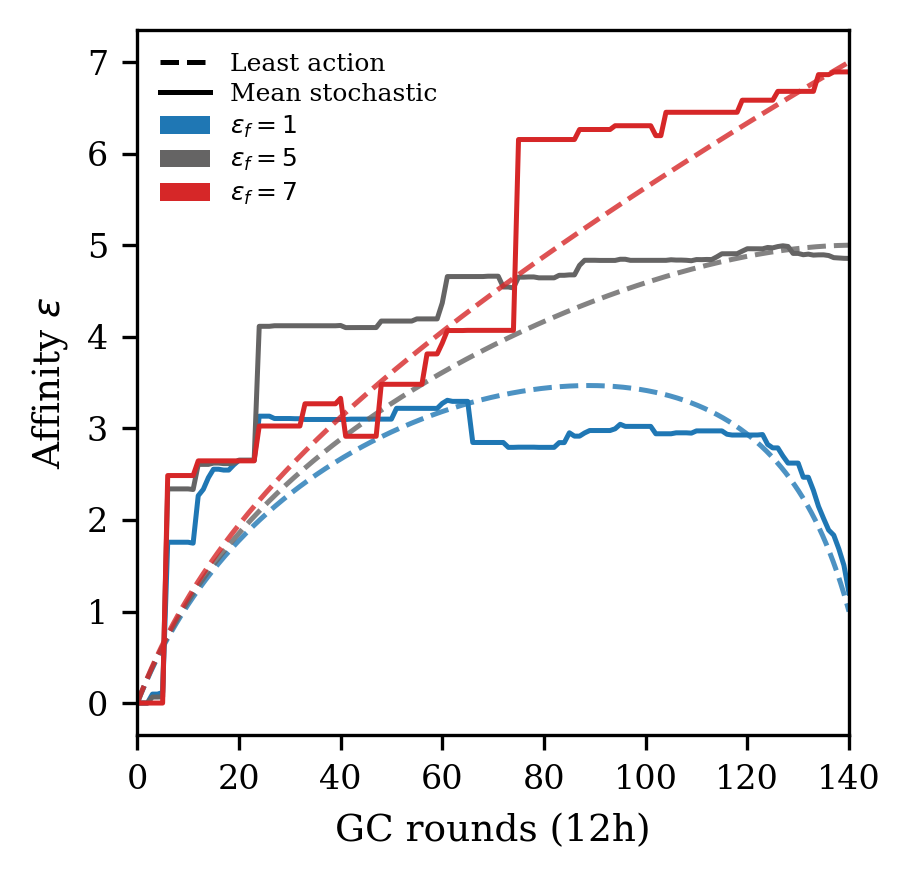

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# --- 1. Publication Style Preferences ---
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.markersize": 4,
    "figure.figsize": (3., 3.),
    "figure.dpi": 300,
    "font.family": "serif",
})

# --- 2. Configuration ---
targets = [1, 5, 7]

# Generate colors from Red to Blue using the 'coolwarm' colormap
# 0.9 gives deep red, 0.1 gives deep blue. We linspace between them.
colors = [plt.cm.coolwarm(x) for x in np.linspace(0.9, 0.1, len(targets))]
colors = [ '#1f77b4',  "#656464",'#d62728']
fig, ax = plt.subplots()

for i, (t_val, color) in enumerate(zip(targets, colors)):
    # --- Identify Stochastic Indices ---
    # Note: final_energies must be defined in your previous context
    target_indices = np.where((final_energies >= t_val - 0.5) & (final_energies < t_val + 0.5))[0]
    print(f"Target {t_val}: Found {len(target_indices)} cells.")

    # --- Plot Least-action (Theory) ---
    try:
        # Note: T_steps must be defined in your previous context
        h_sol = np.loadtxt(f"../multi Ag/trajectory_h_140_{t_val}.csv", delimiter=",")
        n_points = len(h_sol)
        t_sol = np.linspace(0, T_steps, n_points)
        
        # Plot
        ax.plot(t_sol, h_sol, lw=1.2, linestyle='--', color=color, alpha=0.8)
    except OSError:
        print(f"Warning: Could not load trajectory file for target {t_val}")

    # --- Plot Mean Stochastic (Simulation) ---
    if len(target_indices) > 0:
        # Note: trace_lineages and history must be defined in your previous context
        trajectories = trace_lineages(history, target_indices)
        
        h1_by_round = defaultdict(list)
        for traj in trajectories:
            h1 = traj.flatten()
            rounds = np.arange(len(h1))
            for r, h in zip(rounds, h1):
                h1_by_round[r].append(h)
        
        if h1_by_round:
            common_rounds = sorted(h1_by_round.keys())
            mean_h1 = [np.mean(h1_by_round[r]) for r in common_rounds]
            
            # Plot
            ax.plot(common_rounds, mean_h1, lw=1.2, linestyle='-', color=color)

# --- 3. Custom Legend Construction ---
legend_elements = [
    # Line styles (Black)
    Line2D([0], [0], color='black', lw=1.2, linestyle='--', label='Least action'),
    Line2D([0], [0], color='black', lw=1.2, linestyle='-', label='Mean stochastic'),
    
    # Target Colors (Rectangles) - Dynamic reference to the colors list
    Patch(facecolor=colors[0], edgecolor='none', label=r'$\epsilon_f=1$'),
    Patch(facecolor=colors[1], edgecolor='none', label=r'$\epsilon_f=5$'),
    Patch(facecolor=colors[2], edgecolor='none', label=r'$\epsilon_f=7$'),
]

# --- 4. Final Formatting ---
ax.set_xlim(0, T_steps)
ax.set_xlabel("GC rounds (12h)")
ax.set_ylabel(r"Affinity $\epsilon$")

# Add the custom legend
ax.legend(handles=legend_elements, frameon=False, loc="upper left", fontsize=6, labelspacing=0.3)
# ax.set_title(r"Mean vs Theory Trajectories")

fig.tight_layout()
plt.show()

# Histogram last population

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------- Final Affinity Histogram ----------------------
c_array= [10,50,170]
for c in c_array:
    def C_schedule(): return np.array([c])
    
    # Run Simulation
    print(f"Simulating for c={c}...")
    history = simulate_gc_with_ancestry(
        rounds=T_steps,
        S_mat=S_mat,
        N_init=N_i,
        N_max=N_max,
        C_schedule=C_schedule,
        seed=0
    )
    # 1. Extract the final state from history
    final_frame = history[-1]
    final_pop = final_frame['pop']

    # 2. Calculate affinities (energies) for the final population
    final_affinities = energies(final_pop, S_mat).flatten()
    print(f"Final population size for c={c}: {len(final_affinities)}")
    print(final_affinities)

    # Load the csv of results from fokker planck
    fp_filename = f'../multi Ag/rho_epsilon_last_step_c={c}.csv'
    df_fp = pd.read_csv(fp_filename)
    eps_fp = df_fp['epsilon']
    rho_fp = df_fp['rho_epsilon']

    # 3. Create the Histogram Plot
    plt.figure(figsize=(3, 2.6), dpi=300)  # Maintaining your PRL-style sizing

    # Plot histogram of stochastic simulation and CAPTURE the bins
    counts, bins, patches = plt.hist(
        final_affinities, bins=30, color='skyblue', edgecolor='navy', 
        alpha=0.7, label='Stochastic'
    )

    # Calculate the bin width of the stochastic histogram
    bin_width = bins[1] - bins[0]
    
    # Calculate the grid spacing of the Fokker-Planck continuous data
    deps_fp = eps_fp.iloc[1] - eps_fp.iloc[0]
    
    # Scale rho_fp smoothly to match the histogram 'Count' scale.
    # This replaces the need to sum weights into coarse bins.
    scaled_rho_fp = rho_fp * (bin_width / deps_fp)

    # Plot Fokker Planck smoothly using its native resolution
    plt.plot(eps_fp, scaled_rho_fp, color='darkorange', label='Fokker-Planck', linestyle='--')

    # 4. Formatting
    plt.xlabel(r"Affinity $\epsilon$")
    plt.ylabel("Count")

    plt.legend(frameon=False, fontsize='small')
    plt.tight_layout()
    plt.ylim (0, 800)  # Adjust y-limit for better visualization

    plt.show()

Simulating for c=10...


TypeError: C_schedule() takes 0 positional arguments but 1 was given

Simulating for c=10...
rho_fp [6.82184104e-97 1.92797724e-96 6.70354718e-96 2.36640022e-95
 8.33888016e-95 2.92948663e-94 1.02586773e-93 3.58095872e-93
 1.24597835e-92 4.32135833e-92 1.49390868e-91 5.14774685e-91
 1.76805206e-90 6.05275397e-90 2.06531580e-89 7.02410118e-89
 2.38101026e-88 8.04439463e-88 2.70883434e-87 9.09125618e-87
 3.04097689e-86 1.01378424e-85 3.36834511e-85 1.11537706e-84
 3.68092009e-84 1.21064310e-83 3.96822655e-83 1.29626243e-82
 4.21989026e-82 1.36904197e-81 4.42624474e-81 1.42610949e-80
 4.57893923e-80 1.46510004e-79 4.67149587e-79 1.48431781e-78
 4.69976450e-78 1.48285834e-77 4.66223096e-77 1.46067879e-76
 4.56014696e-76 1.41860860e-75 4.39746638e-75 1.35829883e-74
 4.18059185e-74 1.28211434e-73 3.91795396e-73 1.19297859e-72
 3.61946205e-72 1.09418542e-71 3.29587670e-71 9.89194966e-71
 2.95816025e-70 8.81431314e-70 2.61686032e-69 7.74098792e-69
 2.28157482e-68 6.70030256e-68 1.96053497e-67 5.71576779e-67
 1.66032807e-66 4.80543120e-66 1.38576614e-65 3.9816850

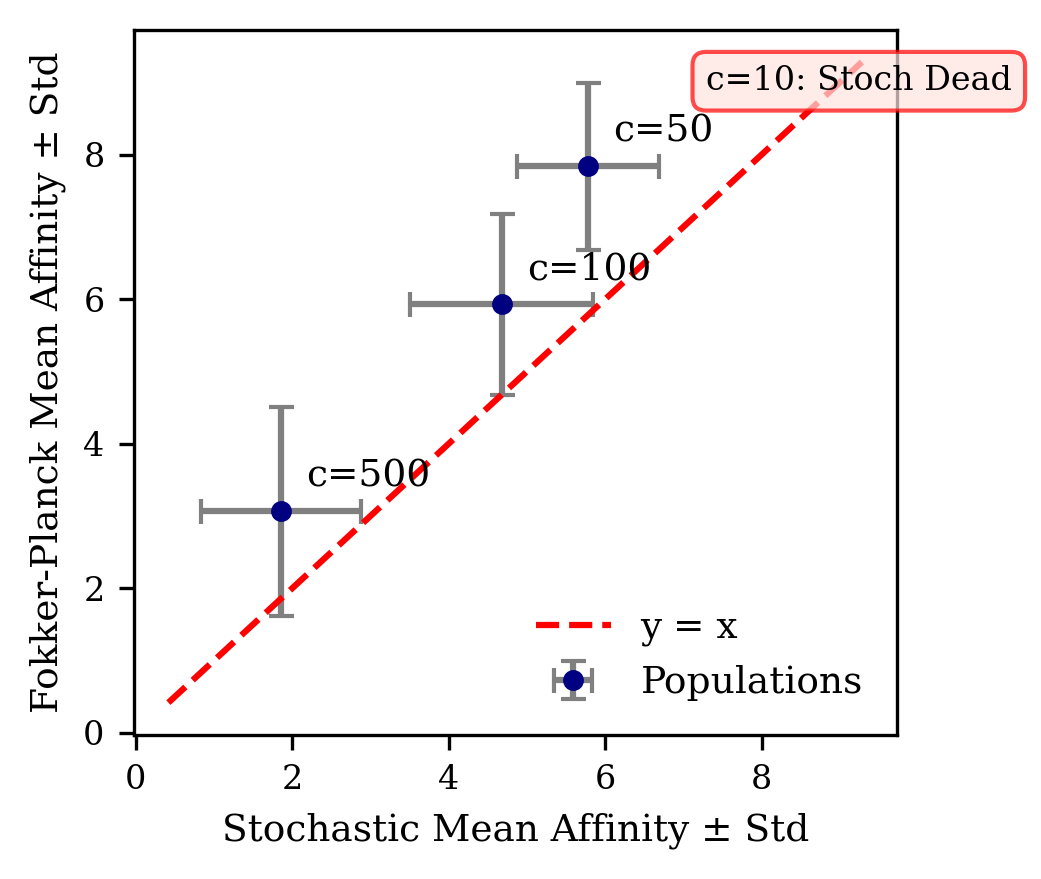

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------- Mean Affinity vs FP Comparison ----------------------
c_array = [10, 50, 100, 500]

stoch_means, stoch_stds = [], []
fp_means, fp_stds = [], []
valid_c = []
dead_c_info = []

for c in c_array:
    def C_schedule(): return np.array([c])
    
    # Run Simulation
    print(f"Simulating for c={c}...")
    history = simulate_gc_with_ancestry(
        rounds=T_steps,
        S_mat=S_mat,
        N_init=N_i,
        N_max=N_max,
        C_schedule=C_schedule,
        seed=0
    )
    # 1. Extract the final state from history
    final_frame = history[-1]
    final_pop = final_frame['pop']

    # 2. Calculate affinities (energies) for the final population
    final_affinities = energies(final_pop, S_mat).flatten()

    # Load the csv of results from fokker planck
    fp_filename = f'../multi Ag/rho_epsilon_last_step_c={c}.csv'
    try:
        df_fp = pd.read_csv(fp_filename)
        eps_fp = df_fp['epsilon'].values
        rho_fp = df_fp['rho_epsilon'].values
    except FileNotFoundError:
        eps_fp, rho_fp = np.array([]), np.array([])

    # 3. Check for dead populations
    stoch_dead = len(final_affinities) == 0
    fp_dead = len(rho_fp) == 0 or not np.sum(rho_fp) > 1 
    print('rho_fp', rho_fp)

    if stoch_dead or fp_dead:
        if stoch_dead and fp_dead:
            status = "Dead"
        elif stoch_dead:
            status = "Stoch Dead"
        else:
            status = "FP Dead"
        
        dead_c_info.append(f"c={c}: {status}")
        continue  # Skip plotting points for dead populations

    # 4. Calculate Stochastic Moments
    stoch_means.append(np.mean(final_affinities))
    stoch_stds.append(np.std(final_affinities))

    # 5. Calculate Fokker-Planck Moments
    total_mass = np.sum(rho_fp)
    mean_fp = np.sum(eps_fp * rho_fp) / total_mass
    
    # Variance = E[X^2] - (E[X])^2
    var_fp = np.sum((eps_fp**2) * rho_fp) / total_mass - (mean_fp**2)
    # Ensure no negative variance due to floating point inaccuracies
    std_fp = np.sqrt(max(0, var_fp)) 

    fp_means.append(mean_fp)
    fp_stds.append(std_fp)
    valid_c.append(c)


# ---------------------- Plotting ----------------------
plt.figure(figsize=(3.5, 3), dpi=300)

if valid_c:
    # Scatter plot with double error bars
    plt.errorbar(
        stoch_means, fp_means, 
        xerr=stoch_stds, yerr=fp_stds, 
        fmt='o', color='navy', ecolor='gray', capsize=3, label='Populations'
    )
    
    # Annotate each point with its concentration
    for i, c in enumerate(valid_c):
        plt.annotate(
            f"c={c}", 
            (stoch_means[i], fp_means[i]), 
            textcoords="offset points", 
            xytext=(6, 6), 
            ha='left', 
            fontsize=9
        )

    # Add reference line y = x to show perfect agreement
    min_val = min(min(stoch_means), min(fp_means)) - max(max(stoch_stds), max(fp_stds))
    max_val = max(max(stoch_means), max(fp_means)) + max(max(stoch_stds), max(fp_stds))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.5, label='y = x')

# If any populations died, list them in a text box on the graph
if dead_c_info:
    text_str = dead_c_info[0]
    plt.gca().text(
        0.75, 0.95, text_str, 
        transform=plt.gca().transAxes,
        fontsize=8, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='mistyrose', edgecolor='red', alpha=0.7)
    )

plt.xlabel("Stochastic Mean Affinity ± Std")
plt.ylabel("Fokker-Planck Mean Affinity ± Std")
# plt.title("Affinity Comparison (Stochastic vs FP)")

plt.legend(frameon=False, loc='lower right')
# plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()

Simulating for c=50 across 10 seeds...
Simulating for c=50...
Simulating for c=50...
Simulating for c=50...
Simulating for c=50...
Simulating for c=50...
Simulating for c=50...
Simulating for c=50...
Simulating for c=50...
Simulating for c=50...
Simulating for c=50...
Simulating for c=100 across 10 seeds...
Simulating for c=100...
Simulating for c=100...
Simulating for c=100...
Simulating for c=100...
Simulating for c=100...
Simulating for c=100...
Simulating for c=100...
Simulating for c=100...
Simulating for c=100...
Simulating for c=100...
Simulating for c=500 across 10 seeds...
Simulating for c=500...
Simulating for c=500...
Simulating for c=500...
Simulating for c=500...
Simulating for c=500...
Simulating for c=500...
Simulating for c=500...
Simulating for c=500...
Simulating for c=500...
Simulating for c=500...


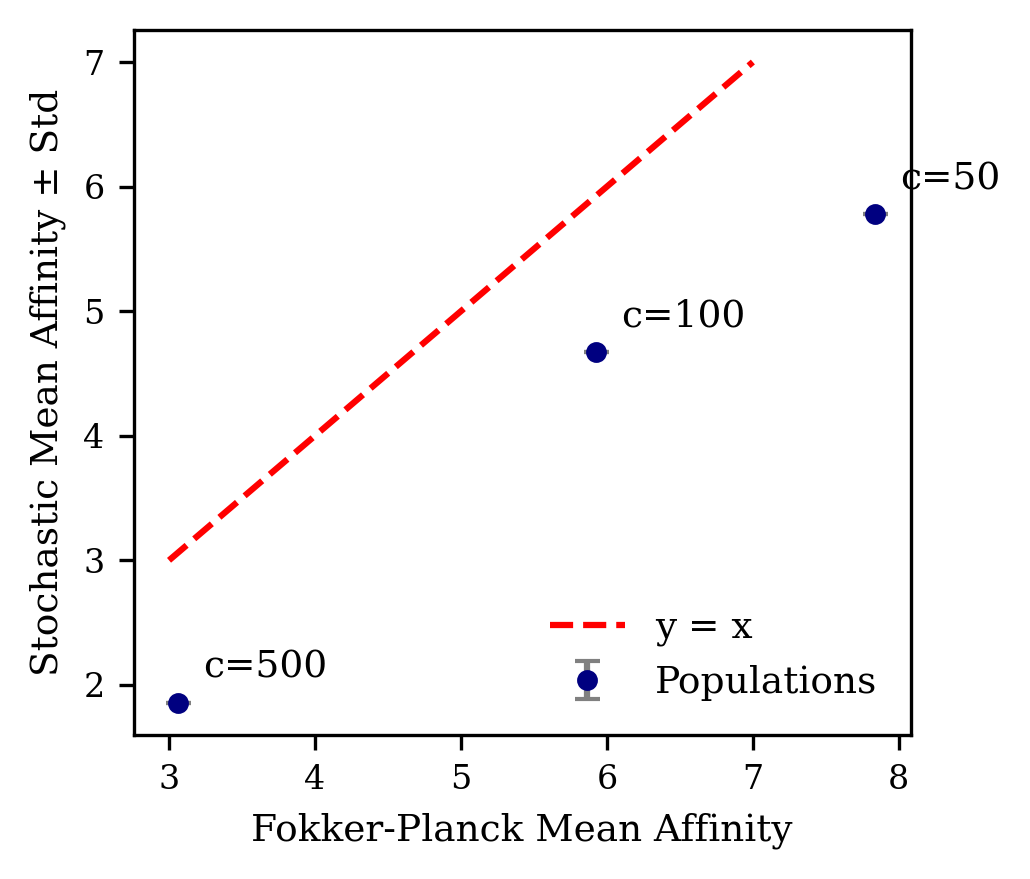

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------- Mean Affinity vs FP Comparison ----------------------
c_array = [50, 100,  500]
N_SEEDS = 10

stoch_means, stoch_stds = [], []
fp_means = []
valid_c = []
dead_c_info = []

for c in c_array:
    def C_schedule(): return np.array([c])
    
    print(f"Simulating for c={c} across {N_SEEDS} seeds...")
    
    seed_mean_affinities = []
    
    # Run Simulation for 10 seeds
    for seed in range(N_SEEDS):
        print(f"Simulating for c={c}...")
        history = simulate_gc_with_ancestry(
            rounds=T_steps,
            S_mat=S_mat,
            N_init=N_i,
            N_max=N_max,
            C_schedule=C_schedule,
            seed=0
        )
        # 1. Extract the final state from history
        final_frame = history[-1]
        final_pop = final_frame['pop']

        # 2. Calculate affinities (energies) for the final population
        final_affinities = energies(final_pop, S_mat).flatten()
        seed_mean_affinities.append(np.mean(final_affinities))

    # Load the csv of results from fokker planck
    fp_filename = f'../multi Ag/rho_epsilon_last_step_c={c}.csv'
    try:
        df_fp = pd.read_csv(fp_filename)
        eps_fp = df_fp['epsilon'].values
        rho_fp = df_fp['rho_epsilon'].values
    except FileNotFoundError:
        eps_fp, rho_fp = np.array([]), np.array([])

    # 3. Check for dead populations
    stoch_dead = len(seed_mean_affinities) < N_SEEDS//2  # If any seed had a dead population, we consider it stoch_dead
    fp_dead = len(rho_fp) == 0 or not np.sum(rho_fp) > 1 

    if stoch_dead or fp_dead:
        if stoch_dead and fp_dead:
            status = "Dead"
        elif stoch_dead:
            status = "Stoch Dead"
        else:
            status = "FP Dead"
        
        dead_c_info.append(f"c={c}: {status}")
        continue  # Skip plotting points for dead populations

    # 4. Calculate Stochastic Moments (across the 10 seeds)
    stoch_means.append(np.mean(seed_mean_affinities))
    stoch_stds.append(np.std(seed_mean_affinities))

    # 5. Calculate Fokker-Planck Mean (no std needed anymore)
    total_mass = np.sum(rho_fp)
    mean_fp = np.sum(eps_fp * rho_fp) / total_mass
    
    fp_means.append(mean_fp)
    valid_c.append(c)


# ---------------------- Plotting ----------------------
plt.figure(figsize=(3.5, 3), dpi=300)

if valid_c:
    # Scatter plot with y-error bars only (FP on X, Stoch on Y)
    plt.errorbar(
        x=fp_means, y=stoch_means, 
        yerr=stoch_stds, 
        fmt='o', color='navy', ecolor='gray', capsize=3, label='Populations'
    )
    
    # Annotate each point with its concentration
    for i, c in enumerate(valid_c):
        plt.annotate(
            f"c={c}", 
            (fp_means[i], stoch_means[i]), 
            textcoords="offset points", 
            xytext=(6, 6), 
            ha='left', 
            fontsize=9
        )


plt.plot([3, 7], [3, 7], 'r--', lw=1.5, label='y = x')

# If any populations died, list them in a text box on the graph
if dead_c_info:
    # Combine all dead info into one string if there are multiple
    text_str = "\n".join(dead_c_info)
    plt.gca().text(
        0.75, 0.95, text_str, 
        transform=plt.gca().transAxes,
        fontsize=8, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='mistyrose', edgecolor='red', alpha=0.7)
    )

plt.xlabel("Fokker-Planck Mean Affinity")
plt.ylabel("Stochastic Mean Affinity ± Std")

plt.legend(frameon=False, loc='lower right')
plt.tight_layout()

plt.show()


Simulating for c=10...
Final population size for c=10: 0
Simulating for c=50...
Final population size for c=50: 2500
Simulating for c=100...
Final population size for c=100: 2500
Simulating for c=170...
Final population size for c=170: 2500
Simulating for c=500...
Final population size for c=500: 2500


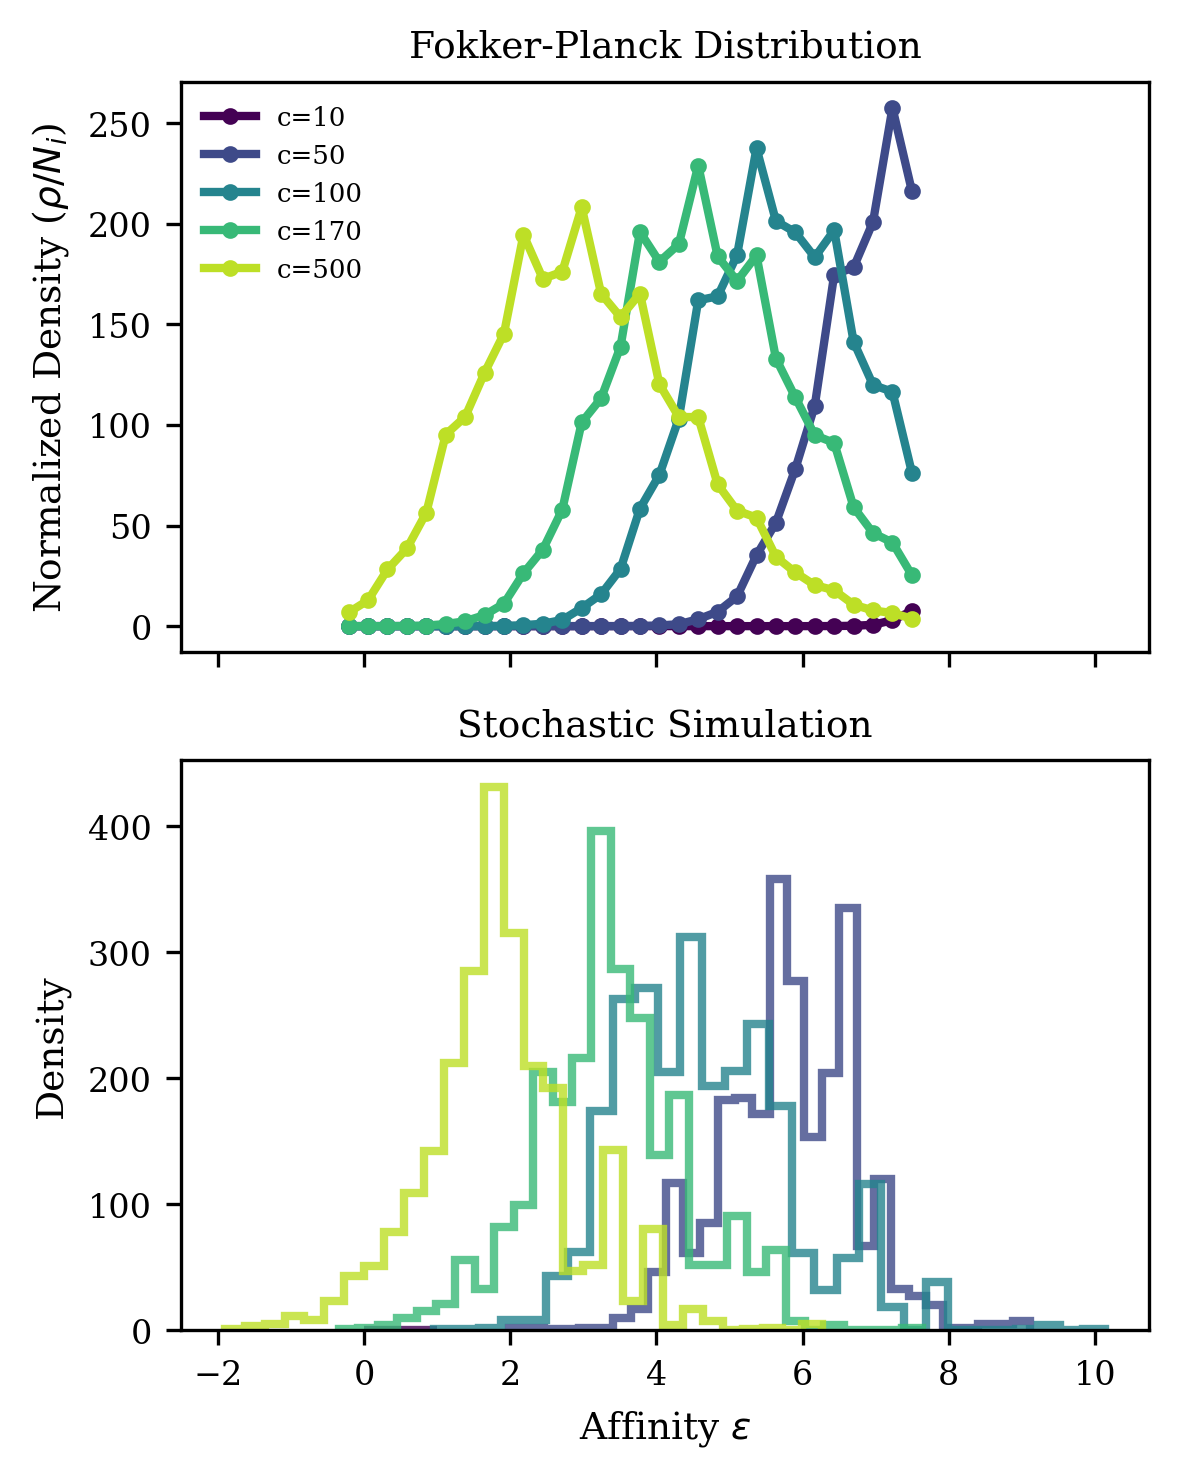

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ---------------------- Final Affinity Distributions ----------------------
c_array = [10, 50, 100, 170, 500]

# 1. Set up the figure with 2 vertically stacked subplots sharing the x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4.0, 5.0), sharex=True)

# Generate a visually distinct set of colors for the different concentrations
colors = cm.viridis(np.linspace(0, 0.9, len(c_array)))

for idx, c in enumerate(c_array):
    color = colors[idx]
    
    def C_schedule(): return np.array([c])
    
    # Run Simulation
    print(f"Simulating for c={c}...")
    history = simulate_gc_with_ancestry(
        rounds=T_steps,
        S_mat=S_mat,
        N_init=N_i,
        N_max=N_max,
        C_schedule=C_schedule,
        seed=0
    )
    
    # Extract the final state from history
    final_frame = history[-1]
    final_pop = final_frame['pop']

    # Calculate affinities (energies) for the final population
    final_affinities = energies(final_pop, S_mat).flatten()
    print(f"Final population size for c={c}: {len(final_affinities)}")

    # Load the csv of results from fokker planck
    fp_filename = f'../multi Ag/rho_epsilon_last_step_c={c}.csv'
    df_fp = pd.read_csv(fp_filename)
    eps_fp = df_fp['epsilon']
    rho_fp = df_fp['rho_epsilon']

    # 2. Plot Fokker-Planck on the Top Subplot (ax1)
    # Normalize by N_i as requested
    fp_normalized = rho_fp #/ N_i 
    fp_counts, _ = np.histogram(eps_fp, bins=bins, weights=rho_fp)
    
    # Calculate bin centers for plotting the FP line
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # Plot Fokker Planck expected bin counts
    ax1.plot(bin_centers, fp_counts, color=color, linewidth=2, marker='o', markersize=3, label=f'c={c}')


    # 3. Plot Stochastic histogram on the Bottom Subplot (ax2)
    # Using histtype='step' draws clear overlapping outlines instead of solid blocks
    ax2.hist(
        final_affinities, bins=30, color=color, 
        histtype='step', linewidth=2, alpha=0.8, density=False, label=f'c={c}'
    )

# 4. Formatting Top Subplot (Fokker-Planck)
ax1.set_ylabel(r"Normalized Density ($\rho / N_i$)")
ax1.set_title("Fokker-Planck Distribution")
ax1.legend(frameon=False, fontsize='x-small', loc='upper left')

# 5. Formatting Bottom Subplot (Stochastic)
ax2.set_xlabel(r"Affinity $\epsilon$")
ax2.set_ylabel("Density")
ax2.set_title("Stochastic Simulation")

plt.tight_layout()
plt.show()

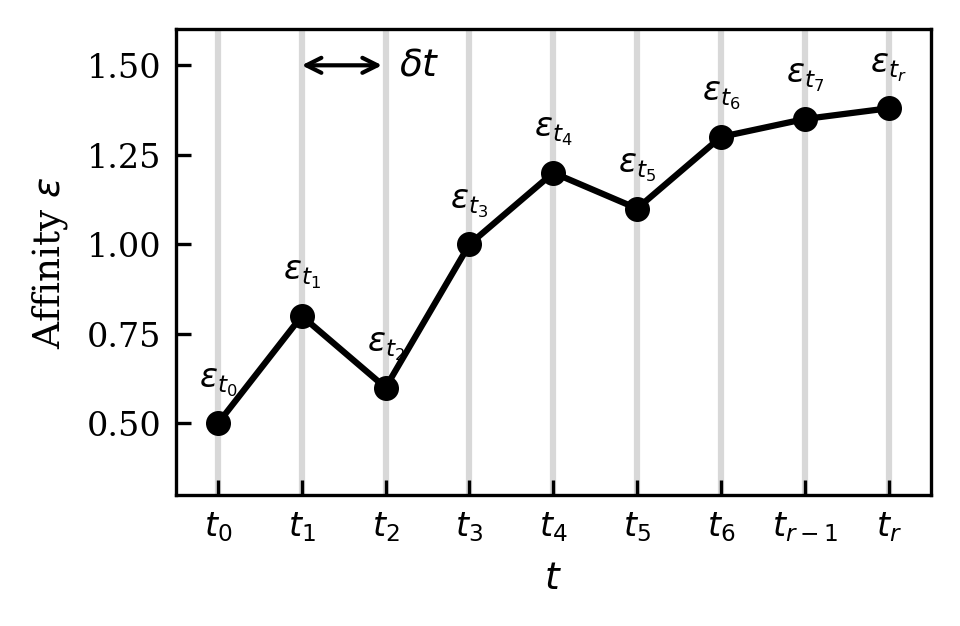

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Sample data resembling schematic trajectory -------------------------
t = np.arange(9)
h = np.array([0.5, 0.8, 0.6, 1.0, 1.2, 1.1, 1.3, 1.35, 1.38])  # example h₁,t values

# --- Create plot ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(3.2, 2.2))  # PRL single column sizing

# Plot points and lines
ax.plot(t, h, 'k-', marker='o', markersize=5, linewidth=1.5)

# Vertical time ticks
for ti in t:
    ax.axvline(ti, color='grey', alpha=0.3, linestyle='-', zorder=0)

# Label each point with h_{1,t_i}
for i, (ti, hi) in enumerate(zip(t, h)):
    label = r"$\epsilon_{t_{%d}}$" % i if i not in [0, len(t)-1] else (
        r"$\epsilon_{t_0}$" if i == 0 else r"$\epsilon_{t_r}$")
    ax.text(ti, hi + 0.07, label, ha='center', va='bottom', fontsize=8)

# Time axis labels
ax.set_xticks(t)
xticklabels = [r"$t_0$", r"$t_1$", r"$t_2$", r"$t_3$", r"$t_4$", r"$t_5$", r"$t_6$", r"$t_{r-1}$", r"$t_r$"]
ax.set_xticklabels(xticklabels, rotation=0)

# Axes labels
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"Affinity $\epsilon$")

# Remove top/right spines
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

# Delta t annotation
ax.annotate(r"$\delta t$",
            xy=(0.9, 1.5), xytext=(2.4, 1.5),
            arrowprops=dict(arrowstyle='<->', lw=1),
            ha='center', va='center', fontsize=9)

# Format
ax.tick_params(direction='in')
ax.set_xlim(-0.5, t[-1] + 0.5)
ax.set_ylim(0.3, 1.6)
fig.tight_layout()
plt.show()


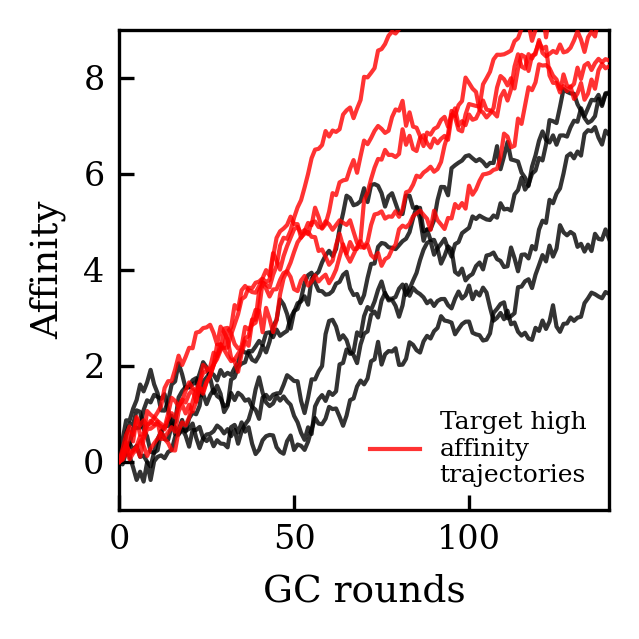

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Synthetic Data Generation (Replace with your actual simulation data) ---
# We simulate 10 random walk trajectories to illustrate the plot.
np.random.seed(42) 
num_trajectories = 10
n_rounds = 140
t = np.arange(n_rounds + 1)

# Generate random paths: cumulative sum of random steps + drift
trajectories = []
drift = 0.05
noise_scale = 0.2

for _ in range(num_trajectories):
    steps = np.random.normal(loc=drift, scale=noise_scale, size=n_rounds)
    path = np.concatenate(([0], np.cumsum(steps)))
    trajectories.append(path)

# --- Create plot (Publishable Format) ------------------------------------
# Using the exact figsize from your previous code (PRL single column)
fig, ax = plt.subplots(figsize=(2.2, 2.2), dpi=300) 

high_affinity_threshold = 7.8
label_added = False # To avoid duplicate legend entries

for i, h in enumerate(trajectories):
    final_affinity = h[-1]
    
    # Determine color and style based on final affinity
    if final_affinity >= high_affinity_threshold:
        color = 'red'
        # Only label the first high-affinity trace to prevent duplicate legend items
        label = "Target high\naffinity\ntrajectories" if not label_added else None
        label_added = True
        zorder = 10 # Bring red lines to front
    else:
        color = 'black'
        label = None
        zorder = 1 # Keep black lines in back

    # Plot the trajectory
    ax.plot(t, h, color=color, linewidth=1.0, alpha=0.8, label=label, zorder=zorder)

# --- Formatting matching your previous plot ------------------------------
# Axis labels
ax.set_xlabel("GC rounds")
ax.set_ylabel("Affinity")

# Ticks styling (Inward direction as requested)
ax.tick_params(direction='in', which='both')

# Set limits
ax.set_xlim(0, n_rounds)
ax.set_ylim(bottom=-1, top=9) # Adjust top limit based on your data

# Simple Legend (frameon=False often looks cleaner in papers)
ax.legend(loc='lower right', frameon=False, fontsize=6)

# Tight layout to ensure labels fit within the small figure size
fig.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------- Mean Affinity vs FP Comparison ----------------------
# c_array = [1, 3, 5, 7, 9, 11, 13]
c_array = np.logspace(-1, 2, 6)  # 10 values from 1 to 1000 on a log scale

N_SEEDS = 20
survival_mean_arr = []

for c in c_array:
    def C_schedule(): return np.array([c])
    
    print(f"Simulating for c={c} across {N_SEEDS} seeds...")
    
    c_survied = 0
    
    # Run Simulation for 10 seeds
    for seed in range(N_SEEDS):
        history = simulate_gc_with_ancestry(
            rounds=T,                
            S_mat=S_mat,
            N_init=N_i,
            N_max=N_max,
            C_schedule=C_schedule,   
            seed=seed,
        )
        
        # Extract the final state from history
        final_frame = history[-1]
        final_pop = final_frame['pop']

        # If population is not dead, calculate and store its mean affinity
        if len(final_pop) > 0:
            c_survied += 1
    survival_mean_arr.append(c_survied / N_SEEDS)

# ---------------------- Plotting ----------------------#save the results to csv
df_survival = pd.DataFrame({
    'c': c_array,
    'survival_rate': survival_mean_arr
})



            
    

Simulating for c=0.1 across 20 seeds...
Simulating for c=0.3981071705534972 across 20 seeds...
Simulating for c=1.5848931924611134 across 20 seeds...
Simulating for c=6.30957344480193 across 20 seeds...
Simulating for c=25.118864315095795 across 20 seeds...
Simulating for c=100.0 across 20 seeds...


Index(['c', 'rho_c', 'survival_rate'], dtype='object')


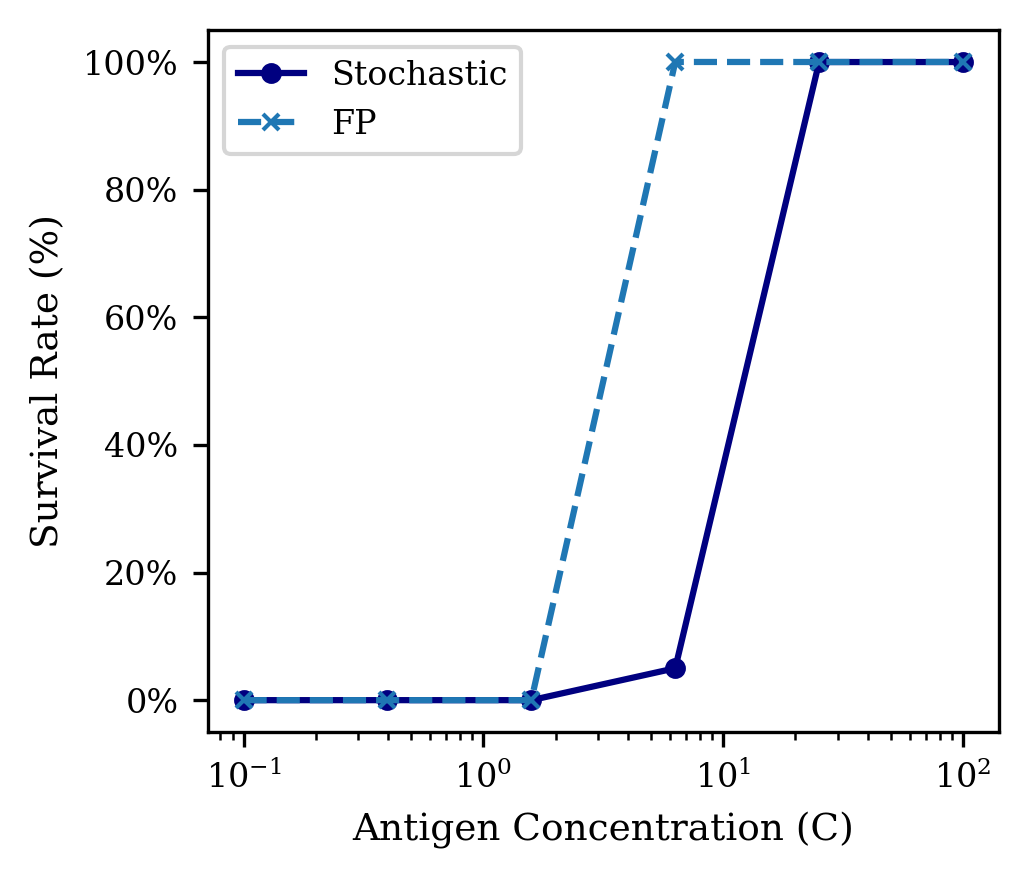

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
df_survival_fp = pd.read_csv('../multi Ag/survival_rate_fp_log.csv')
print(df_survival_fp.columns)
#Index(['c', 'rho_c', 'survival_rate'], dtype='object')

import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.figure(figsize=(3.5, 3), dpi=300)

# Plot your first dataset
plt.plot(c_array, survival_mean_arr, marker='o', color='navy', label='Stochastic')

# Group the Fokker-Planck dataframe by rho_c to plot a line for each parameter set
for rho_c, group in df_survival_fp.groupby('rho_c'):
    if rho_c != 0:
        continue
    # Sorting by 'c' ensures the line connects points left-to-right correctly
    group = group.sort_values(by='c')
    # plt.plot(group['c'], group['survival_rate'], marker='x', linestyle='--', label=rf'FP ($\rho_c={rho_c}$)')
    plt.plot(group['c'], group['survival_rate'], marker='x', linestyle='--', label='FP')


plt.xlabel("Antigen Concentration (C)")
plt.ylabel("Survival Rate (%)")
# plt.title("Survival Rate vs Antigen Concentration")
plt.xscale('log')  # Set x-axis to logarithmic scale

# Format the y-axis ticks as percentages (assuming your raw data is in fractions 0.0 to 1.0)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

plt.legend(fontsize=8)
# plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Optimal protocols

In [33]:
df_conc=pd.read_csv('../multi Ag/c_star_over_time.csv')
def C_schedule(t):
    # Interpolate the concentration value at time t from the dataframe
    return np.interp(t, df_conc['time'], df_conc['c_star'])
C_schedule(140)



1.4742278101958328

Simulating for c=170...
Final population size for c=170: 16
[22.10908751 22.10908751 23.94480084 23.94480084 23.94480084 23.94480084
 23.94480084 23.94480084 23.94480084 23.94480084 23.94480084 23.94480084
 23.94480084 23.94480084 23.94480084 23.94480084]
Final population size for c=170: 16


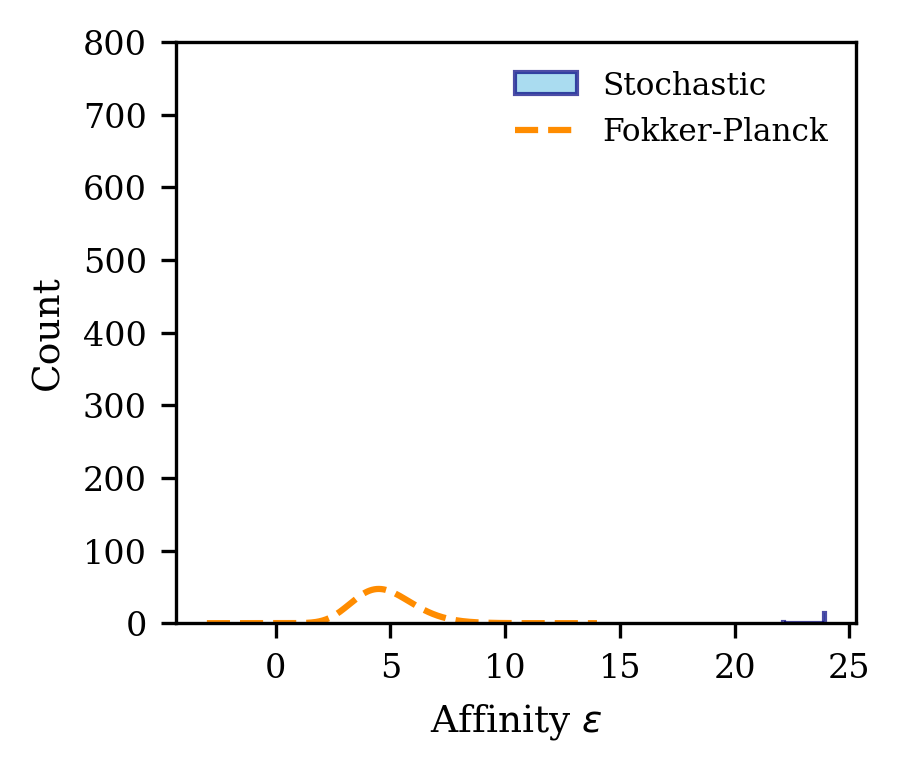

Simulating for c=170...
Final population size for c=170: 120
[20.21650636 20.21650636 20.21650636 20.21650636 21.15439109 21.15439109
 21.15439109 21.15439109 21.15439109 21.15439109 21.15439109 21.15439109
 21.15439109 21.15439109 21.15439109 21.15439109 21.15439109 21.15439109
 21.15439109 21.15439109 21.15439109 21.15439109 21.15439109 21.15439109
 20.8446992  21.15439109 21.15439109 20.15662932 20.15662932 21.15439109
 21.15439109 21.15439109 21.15439109 21.15439109 21.15439109 21.15439109
 21.15439109 21.15439109 21.15439109 21.15439109 21.15439109 21.15439109
 21.15439109 21.15439109 21.15439109 21.15439109 21.15439109 21.15439109
 21.15439109 21.15439109 21.15439109 21.15439109 21.15439109 21.15439109
 21.15439109 21.15439109 21.15439109 21.15439109 21.15439109 21.93877414
 21.93877414 21.15439109 20.87312983 20.87312983 20.87312983 21.15439109
 21.15439109 21.15439109 21.15439109 21.15439109 21.15439109 21.15439109
 21.15439109 21.15439109 21.15439109 21.15439109 21.15439109 21

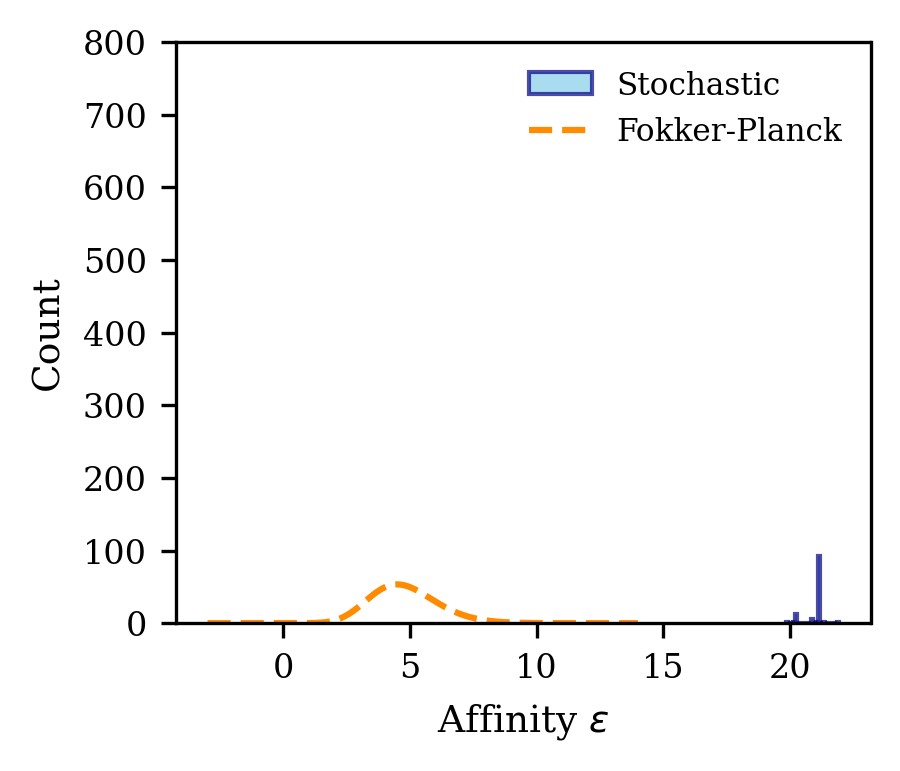

Simulating for c=170...
Final population size for c=170: 163
[19.21351245 19.21351245 19.21351245 19.21351245 19.21351245 19.21351245
 19.21351245 19.21351245 19.21351245 19.21351245 19.21351245 19.21351245
 19.21351245 19.21351245 19.21351245 19.21351245 19.21351245 19.21351245
 19.21351245 19.21351245 19.21351245 19.21351245 19.21351245 19.21351245
 19.21351245 19.21351245 19.21351245 19.21351245 19.21351245 19.21351245
 19.21351245 19.21351245 19.21351245 19.21351245 19.21351245 19.21351245
 19.21351245 18.98655072 18.98655072 18.98655072 18.98655072 19.21351245
 19.21351245 19.21351245 18.70114981 18.70114981 18.70114981 18.70114981
 18.70114981 18.70114981 18.70114981 18.70114981 19.47344089 19.47344089
 19.47344089 19.47344089 19.47344089 19.47344089 19.47344089 19.47344089
 19.47344089 19.47344089 19.47344089 19.47344089 19.47344089 19.47344089
 19.47344089 19.47344089 19.47344089 19.47344089 19.47344089 19.47344089
 19.47344089 19.47344089 19.47344089 19.47344089 19.47344089 19

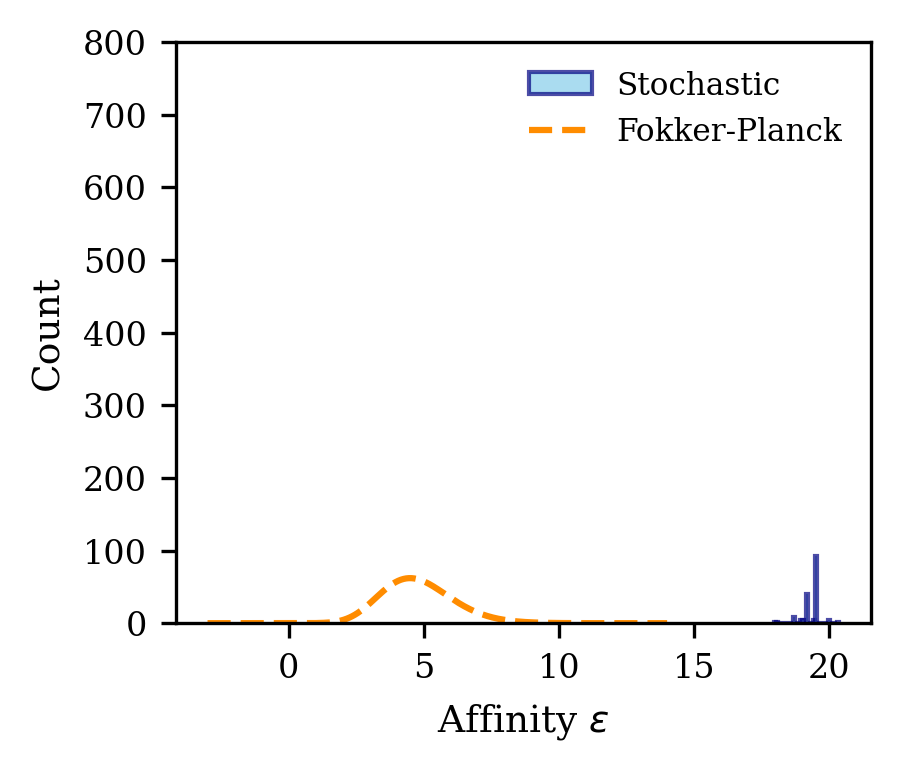

Simulating for c=170...
Final population size for c=170: 184
[20.92749416 20.92749416 20.42167746 20.92749416 20.92749416 20.92749416
 20.92749416 20.92749416 20.92749416 20.92749416 20.92749416 19.98778544
 19.98778544 19.98778544 20.29008042 20.29008042 19.05737251 19.81316957
 19.81316957 20.29008042 20.29008042 20.45757412 20.45757412 20.63218518
 20.63218518 20.63218518 20.63218518 20.95367411 20.95367411 20.95367411
 20.95367411 20.95367411 20.95367411 20.95367411 20.95385637 20.95385637
 20.95385637 20.95385637 20.95385637 20.95385637 20.95385637 20.95385637
 20.95385637 20.95385637 20.95385637 20.95385637 20.95385637 20.95385637
 20.95385637 20.95385637 20.95385637 20.95385637 20.95385637 20.95385637
 20.95385637 20.95385637 22.18810278 20.95385637 20.95385637 20.95385637
 20.95385637 20.95385637 20.95385637 20.95385637 20.95385637 20.95385637
 20.95385637 20.95385637 20.95385637 20.95385637 20.95385637 22.35744279
 20.95385637 20.95385637 20.95385637 20.95385637 20.95385637 20

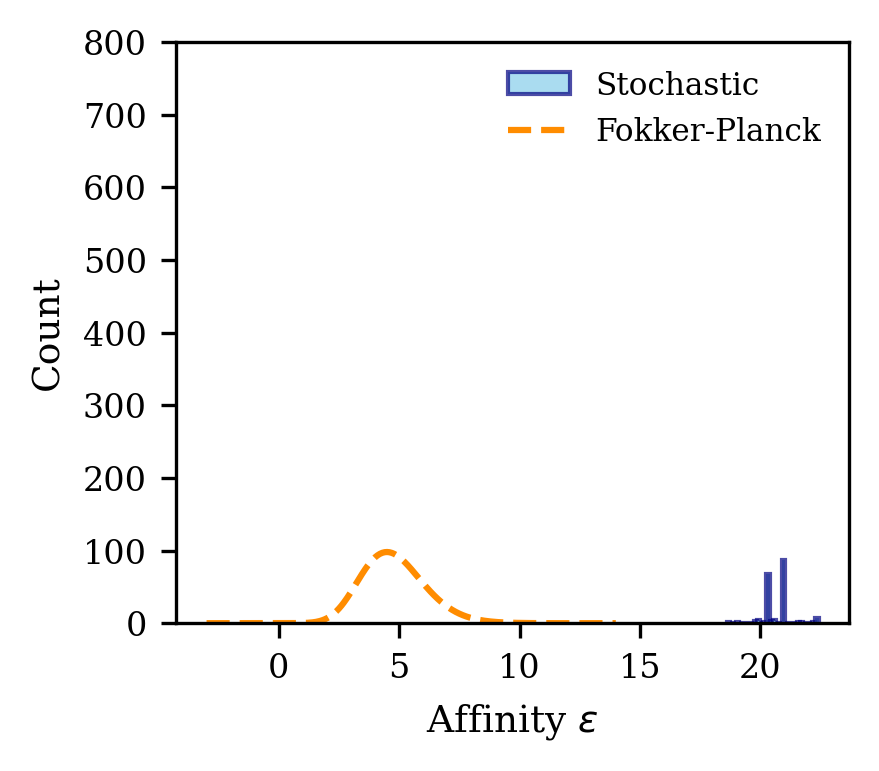

Simulating for c=170...
Final population size for c=170: 28
[22.86384181 22.67464223 22.86384181 22.86384181 22.86384181 22.86384181
 22.86384181 22.86384181 22.86384181 22.86384181 22.86384181 22.86384181
 22.86384181 22.86384181 22.86384181 22.86384181 22.86384181 22.86384181
 22.86384181 22.86384181 22.86384181 22.86384181 22.86384181 22.86384181
 22.86384181 22.34861744 22.86384181 22.86384181]
Final population size for c=170: 28


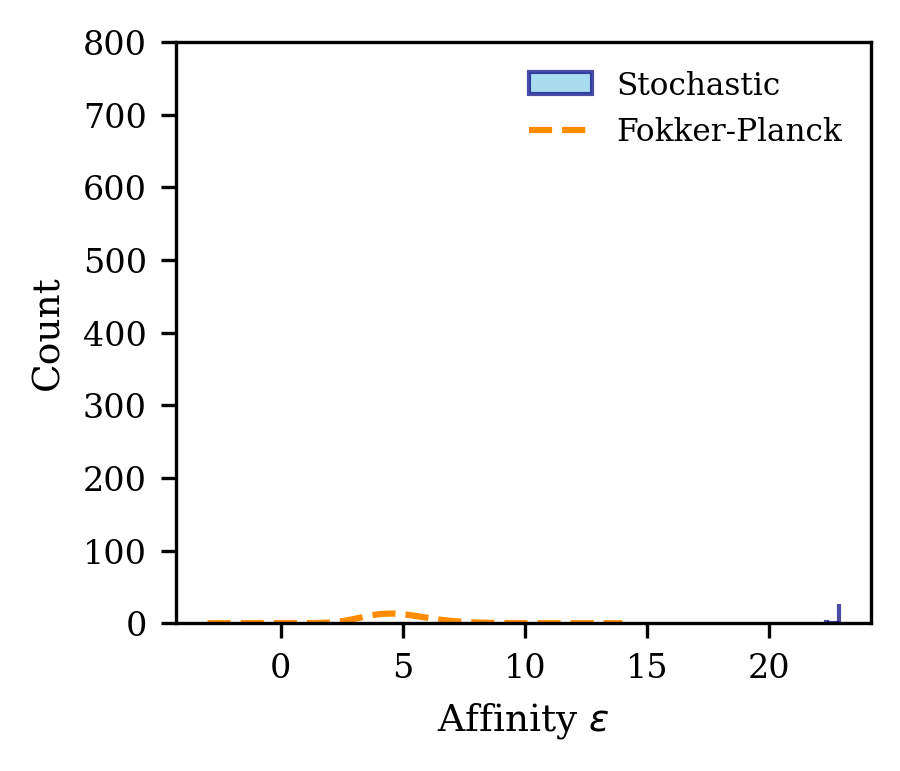

Simulating for c=170...
Final population size for c=170: 18
[22.56053367 22.56053367 22.56053367 22.56053367 22.56053367 22.56053367
 22.56053367 22.56053367 22.56053367 22.56053367 22.56053367 22.56053367
 22.56053367 22.56053367 22.56053367 22.56053367 22.56053367 20.45470172]
Final population size for c=170: 18


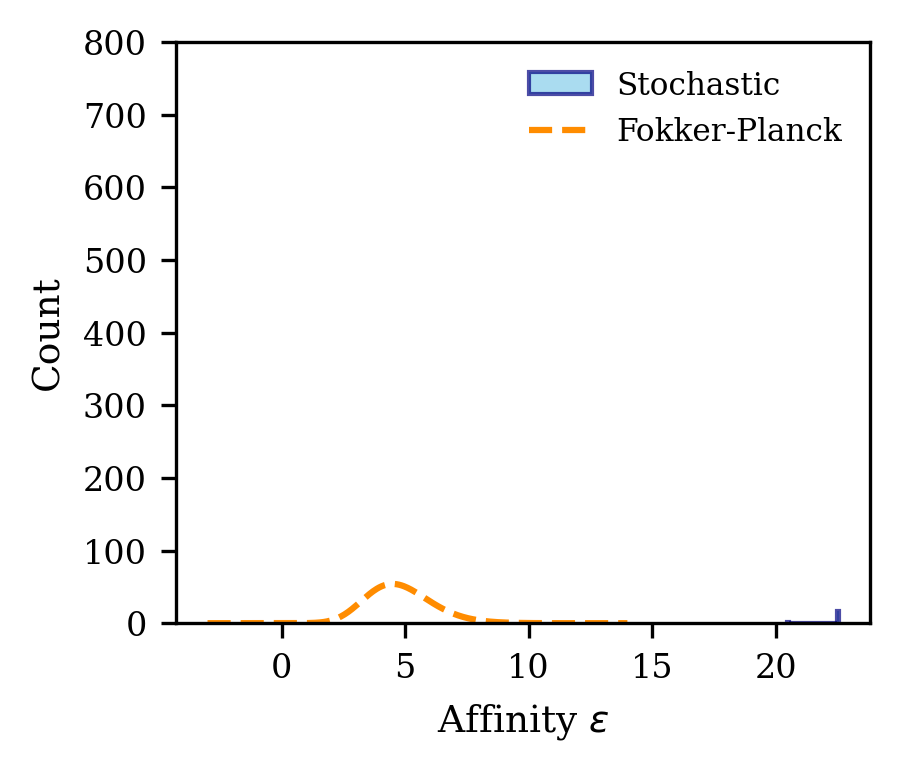

Simulating for c=170...
Final population size for c=170: 108
[20.52664305 20.52664305 20.52664305 20.52664305 20.52664305 20.52664305
 20.52664305 20.52664305 20.52664305 20.52664305 20.52664305 19.62476767
 20.52664305 20.52664305 20.52664305 20.52664305 20.52664305 20.52664305
 20.52664305 20.52664305 20.52664305 20.52664305 20.52664305 20.52664305
 20.52664305 20.52664305 20.52664305 20.52664305 20.52664305 20.52664305
 20.52664305 20.52664305 20.42696386 20.52664305 20.52664305 20.52664305
 20.52664305 20.52664305 20.52664305 20.52664305 20.52664305 20.52664305
 19.65802949 20.52664305 20.52664305 20.52664305 20.52664305 20.52664305
 20.52664305 20.52664305 20.52664305 20.52664305 20.52664305 20.52664305
 20.52664305 20.52664305 20.52664305 20.52664305 20.52664305 20.52664305
 20.52664305 20.52664305 20.52664305 20.52664305 20.52664305 20.52664305
 20.52664305 20.52664305 20.52664305 20.52664305 20.52664305 20.52664305
 20.52664305 19.63646249 20.52664305 19.68425134 19.68425134 19

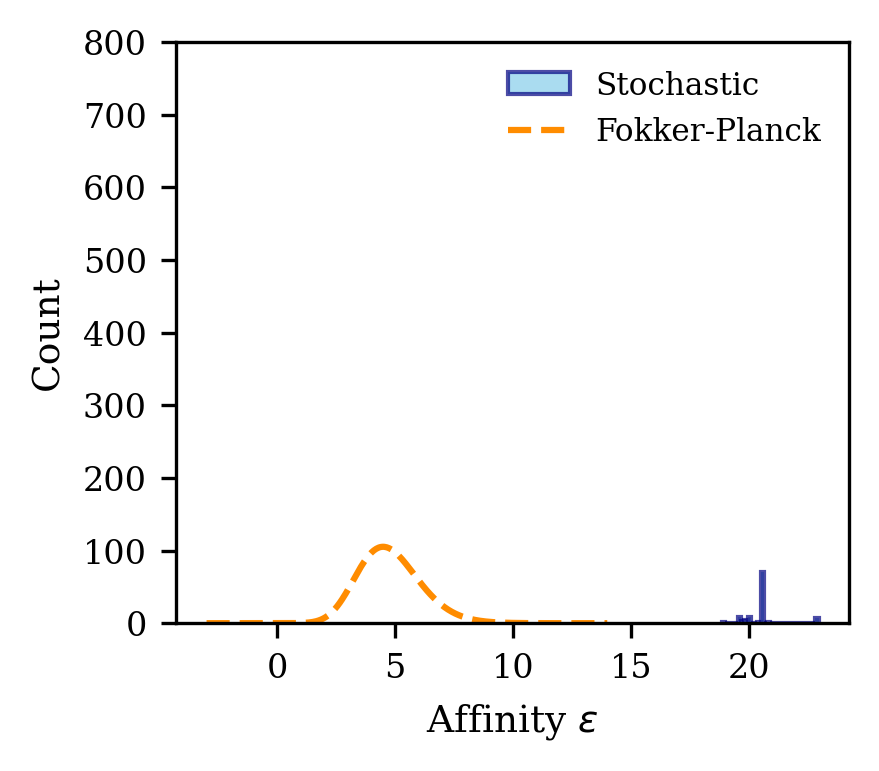

Simulating for c=170...
Final population size for c=170: 3
[23.56249375 23.56249375 23.56249375]
Final population size for c=170: 3


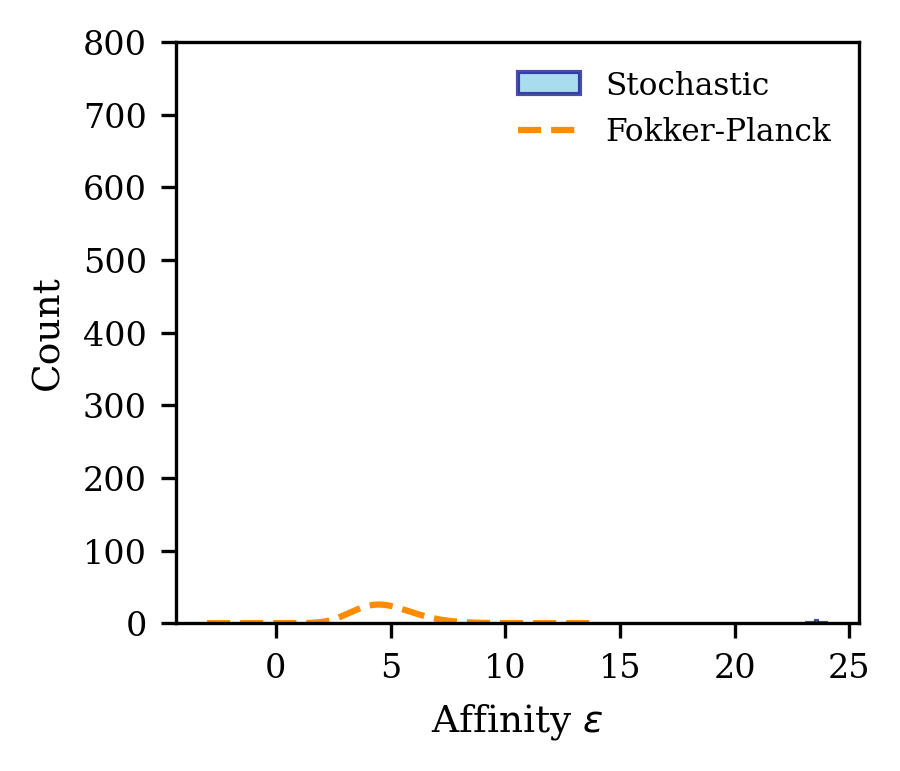

Simulating for c=170...
Final population size for c=170: 82
[20.15726473 22.23692555 22.23692555 22.23692555 22.23692555 22.23692555
 22.23692555 22.23692555 22.23692555 22.23692555 22.23692555 22.23692555
 22.23692555 22.23692555 22.23692555 22.23692555 22.23692555 22.23692555
 22.23692555 22.23692555 22.23692555 22.23692555 22.23692555 22.23692555
 22.23692555 22.23692555 22.23692555 22.23692555 22.23692555 22.23692555
 22.23692555 22.23692555 22.23692555 22.23692555 22.23692555 22.23692555
 22.23692555 20.83573776 22.23692555 22.23692555 22.23692555 22.23692555
 22.23692555 22.23692555 22.23692555 22.23692555 22.23692555 22.23692555
 22.23692555 22.23692555 22.23692555 22.23692555 22.23692555 22.23692555
 22.23692555 22.23692555 22.23692555 22.23692555 22.23692555 22.23692555
 22.23692555 22.23692555 22.23692555 22.23692555 22.23692555 22.23692555
 22.23692555 22.23692555 22.23692555 22.23692555 22.23692555 22.23692555
 20.56901416 20.56901416 19.83078395 20.56901416 21.40615515 21.

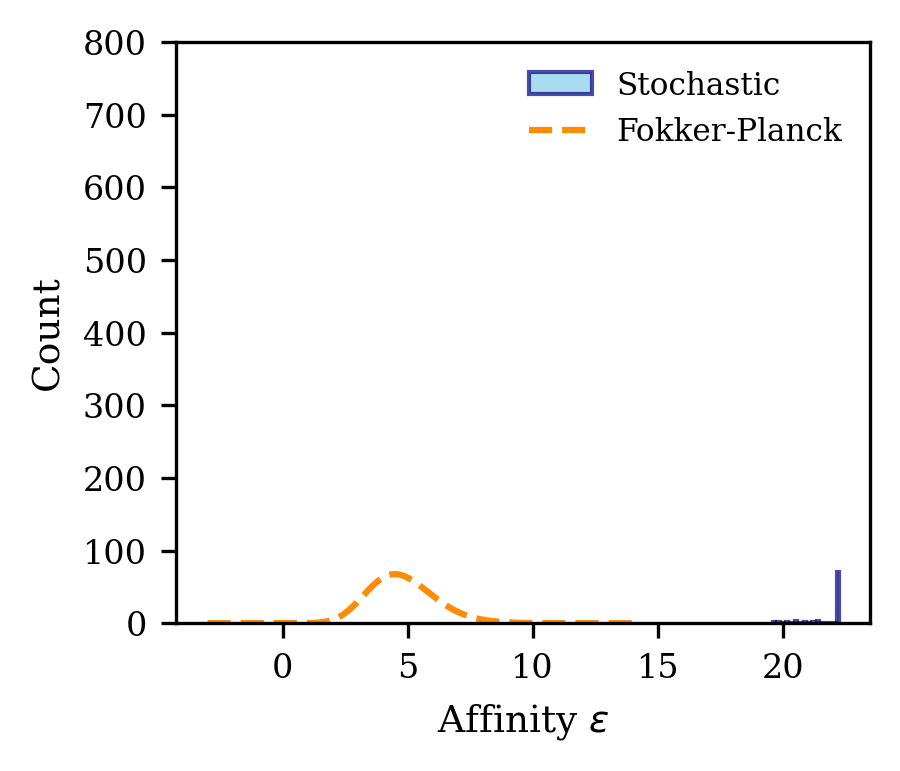

Simulating for c=170...
Final population size for c=170: 21
[23.03169878 22.53485003 22.81615416 22.81615416 22.81615416 22.81615416
 22.81615416 23.04311865 23.04311865 23.04311865 24.20985554 24.20985554
 24.20985554 24.20985554 24.20985554 24.20985554 24.20985554 24.20985554
 22.41338238 22.41338238 22.41338238]
Final population size for c=170: 21


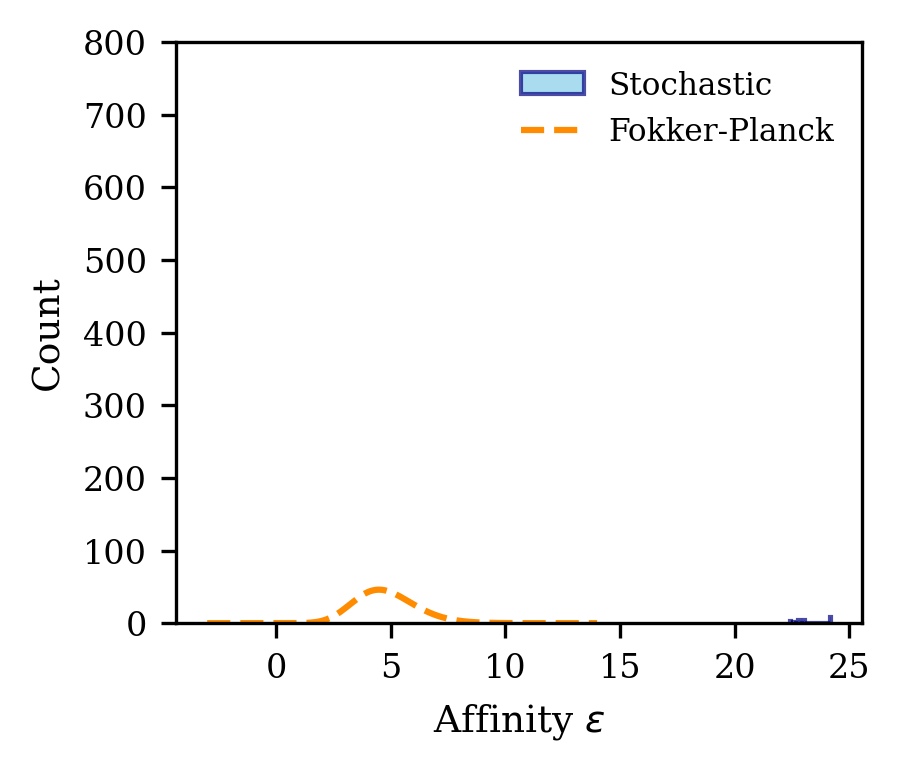

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------- Final Affinity Histogram ----------------------
c=170
for seed in range(10):
    
    # Run Simulation
    print(f"Simulating for c={c}...")
    history = simulate_gc_with_ancestry(
        rounds=T_steps,
        S_mat=S_mat,
        N_init=N_i,
        N_max=N_max,
        C_schedule=C_schedule,
        seed=seed
    )
    # 1. Extract the final state from history
    final_frame = history[-1]
    final_pop = final_frame['pop']

    # 2. Calculate affinities (energies) for the final population
    final_affinities = energies(final_pop, S_mat).flatten()
    print(f"Final population size for c={c}: {len(final_affinities)}")
    print(final_affinities)

    # Load the csv of results from fokker planck
    fp_filename = f'../multi Ag/rho_epsilon_last_step_c={c}.csv'
    df_fp = pd.read_csv(fp_filename)
    eps_fp = df_fp['epsilon']
    rho_fp = df_fp['rho_epsilon']

    #print population size and affinities
    print(f"Final population size for c={c}: {len(final_affinities)}")

    # 3. Create the Histogram Plot
    plt.figure(figsize=(3, 2.6), dpi=300)  # Maintaining your PRL-style sizing

    # Plot histogram of stochastic simulation and CAPTURE the bins
    counts, bins, patches = plt.hist(
        final_affinities, bins=30, color='skyblue', edgecolor='navy', 
        alpha=0.7, label='Stochastic'
    )

    # Calculate the bin width of the stochastic histogram
    bin_width = bins[1] - bins[0]
    
    # Calculate the grid spacing of the Fokker-Planck continuous data
    deps_fp = eps_fp.iloc[1] - eps_fp.iloc[0]
    
    # Scale rho_fp smoothly to match the histogram 'Count' scale.
    # This replaces the need to sum weights into coarse bins.
    scaled_rho_fp = rho_fp * (bin_width / deps_fp)

    # Plot Fokker Planck smoothly using its native resolution
    plt.plot(eps_fp, scaled_rho_fp, color='darkorange', label='Fokker-Planck', linestyle='--')

    # 4. Formatting
    plt.xlabel(r"Affinity $\epsilon$")
    plt.ylabel("Count")

    plt.legend(frameon=False, fontsize='small')
    plt.tight_layout()
    plt.ylim (0, 800)  # Adjust y-limit for better visualization

    plt.show()